<a href="https://colab.research.google.com/github/KevinCallejas93/parcial4/blob/main/Parcial4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# 1. Cargamos el archivo de transacciones
df_asoc = pd.read_csv('clave_I_asociacion.csv')

# 2. Inspección inicial: ¿Qué tenemos aquí?
print("--- PRIMERAS FILAS ---")
print(df_asoc.head())

print("\n--- DIMENSIONES DEL DATASET ---")
print(f"Filas: {df_asoc.shape[0]}, Columnas: {df_asoc.shape[1]}")

# 3. Validación de calidad (Nulos y Duplicados)
print("\n--- VALORES NULOS ---")
print(df_asoc.isnull().sum())

print("\n--- REGISTROS DUPLICADOS ---")
print(df_asoc.duplicated().sum())

# Limpieza rápida: eliminamos nulos si los hay para que no den error después
df_asoc = df_asoc.dropna()

--- PRIMERAS FILAS ---
  transaccion_id cliente_id       fecha categoria            item  cantidad  \
0        I-T0001    I-C0019  2026-03-11   Bebidas            Agua         2   
1        I-T0001    I-C0019  2026-03-11    Combos  Combo_infantil         2   
2        I-T0001    I-C0019  2026-03-11   Postres     Tres_leches         1   
3        I-T0002    I-C0071  2026-04-11   Postres          Helado         3   
4        I-T0002    I-C0071  2026-04-11    Platos           Pizza         1   

    canal  
0     App  
1     App  
2     App  
3  Tienda  
4  Tienda  

--- DIMENSIONES DEL DATASET ---
Filas: 679, Columnas: 7

--- VALORES NULOS ---
transaccion_id    0
cliente_id        0
fecha             0
categoria         0
item              0
cantidad          0
canal             1
dtype: int64

--- REGISTROS DUPLICADOS ---
1


In [2]:
from itertools import combinations

# 1. Transformamos los datos a formato "Canasta" (Basket)
# Agrupamos por transaccion_id e item para ver qué productos aparecen juntos
basket = df_asoc.groupby(['transaccion_id', 'item'])['cantidad'].count().unstack().fillna(0)
basket_bool = (basket > 0)

# 2. Generamos las reglas de asociación (Pares de productos)
reglas = []
columnas = basket_bool.columns

for itemset in combinations(columnas, 2):
    itemset = list(itemset)
    soporte_itemset = basket_bool[itemset].all(axis=1).mean()

    # Filtramos por soporte mínimo del 5% (frecuencia en el dataset)
    if soporte_itemset >= 0.05:
        for i in range(2):
            ant, cons = [itemset[i]], [itemset[1-i]]
            sop_ant = basket_bool[ant].all(axis=1).mean()
            confianza = soporte_itemset / sop_ant

            # Filtramos por confianza mínima del 30%
            if confianza >= 0.30:
                reglas.append({
                    'Antecedente': ant[0],
                    'Consecuente': cons[0],
                    'Soporte': soporte_itemset,
                    'Confianza': confianza,
                    'Lift': confianza / basket_bool[cons].all(axis=1).mean()
                })

# 3. Creamos la tabla final con los mejores resultados
reglas_df = pd.DataFrame(reglas).sort_values(by='Confianza', ascending=False)
print("--- LAS 10 REGLAS MÁS RELEVANTES ---")
print(reglas_df.head(10))

--- LAS 10 REGLAS MÁS RELEVANTES ---
       Antecedente     Consecuente   Soporte  Confianza      Lift
8            Papas     Hamburguesa  0.131707   0.750000  3.137755
12           Papas            Soda  0.117073   0.666667  1.708333
9      Hamburguesa            Soda  0.131707   0.551020  1.411990
7      Hamburguesa           Papas  0.131707   0.551020  3.137755
4           Helado  Combo_infantil  0.136585   0.549020  2.164404
15           Pizza            Soda  0.146341   0.545455  1.397727
3   Combo_infantil          Helado  0.136585   0.538462  2.164404
0             Cafe           Pasta  0.102439   0.525000  2.562500
1            Pasta            Cafe  0.102439   0.500000  2.562500
11          Nachos            Soda  0.058537   0.444444  1.138889


--- 1. CARGA DE DATOS ---
  cliente_id  edad  ingresos_mensuales  frecuencia_compra  ticket_promedio  \
0    I-C0001    18                1208                  8            70.27   
1    I-C0002    38                1221                  7            77.75   
2    I-C0003    45                1385                  8            84.56   
3    I-C0004    48                1044                  4            71.45   
4    I-C0005    31                 808                  5            51.72   

   satisfaccion  reclamos  uso_app  tiempo_respuesta  consumo_total  
0          6.38         4        5             33.92         442.88  
1          7.44         2        6             22.83         543.68  
2          6.56         3        6             29.00         641.28  
3          4.79         4        4             29.42         262.21  
4          7.92         1        4             19.00         321.18  

--- 2. NULOS Y VARIABLES NUMÉRICAS ---
Valores Nulos por columna:
 cliente_id       

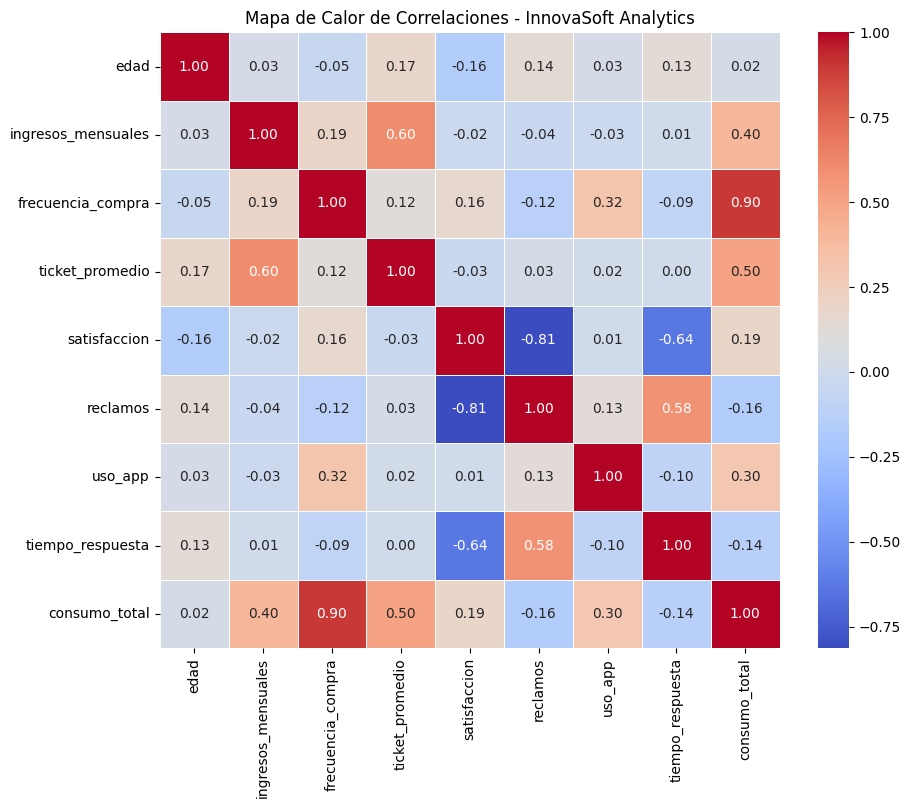

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Cargar el archivo CSV
df_corr = pd.read_csv('clave_I_correlacion.csv')
print("--- 1. CARGA DE DATOS ---")
print(df_corr.head())

# 2. Identificar variables numéricas y revisar nulos
print("\n--- 2. NULOS Y VARIABLES NUMÉRICAS ---")
print("Valores Nulos por columna:\n", df_corr.isnull().sum())
num_cols = df_corr.select_dtypes(include=[np.number]).columns
print("\nVariables numéricas identificadas:", list(num_cols))

# Limpieza rápida: Eliminamos los nulos detectados para no arruinar el cálculo
df_corr = df_corr.dropna()

# 3. Revisar valores atípicos (usando la regla de la media +/- 2 desviaciones)
print("\n--- 3. VALORES ATÍPICOS ---")
for col in num_cols:
    if col != 'cliente_id': # ignoramos el ID
        media = df_corr[col].mean()
        desv = df_corr[col].std()
        lim_inf = media - 2 * desv
        lim_sup = media + 2 * desv
        atipicos = df_corr[(df_corr[col] < lim_inf) | (df_corr[col] > lim_sup)]
        print(f"{col}: {len(atipicos)} valores atípicos detectados")

# 4. Calcular la Matriz de Correlación
matriz_corr = df_corr[num_cols].corr()

# 5. Crear el Mapa de Calor (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Calor de Correlaciones - InnovaSoft Analytics')
plt.show()

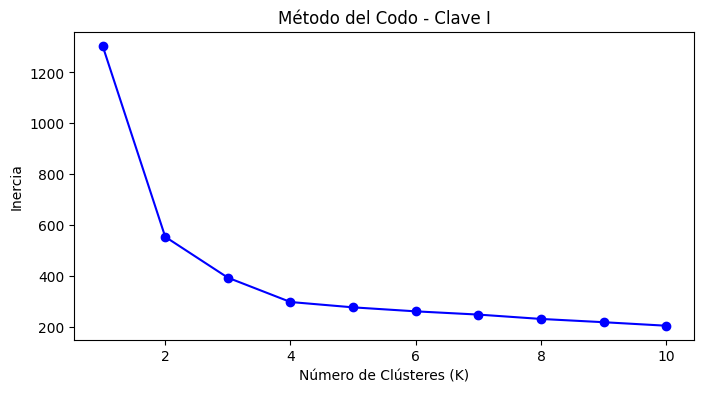


--- PERFILES DE LOS GRUPOS (CENTROIDES) ---
         ingresos  frecuencia_uso  gasto_promedio  satisfaccion  reclamos
Cluster                                                                  
0          839.28            3.00           46.79          5.50      4.03
1         1834.26            8.93          161.47          8.62      0.79
2         1125.10            6.73           95.52          8.22      1.36


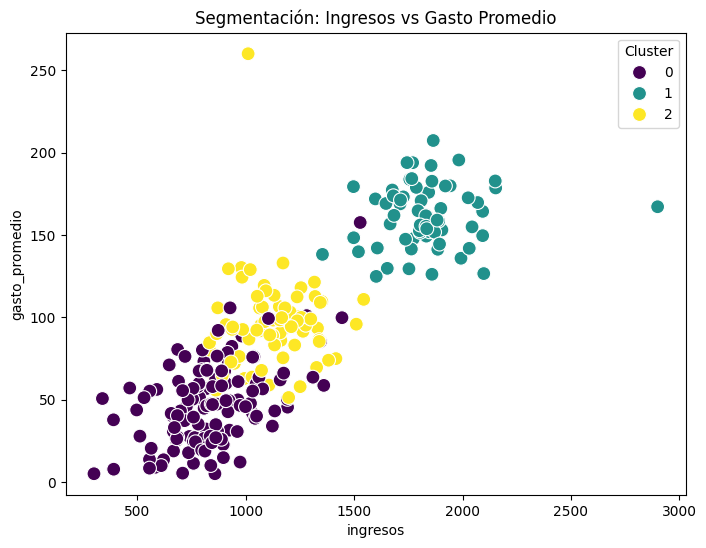

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Cargar y limpiar datos
df_agrup = pd.read_csv('clave_I_agrupacion.csv')
df_agrup = df_agrup.dropna() # Quitamos un nulo para evitar errores

# 2. Selección de variables para el clustering
cols_cluster = ['ingresos', 'frecuencia_uso', 'gasto_promedio', 'satisfaccion', 'reclamos']
X = df_agrup[cols_cluster]

# 3. Normalizar (Escalar) los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Método del Codo para justificar la cantidad de grupos
inercias = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inercias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), inercias, marker='o', color='b')
plt.title('Método del Codo - Clave I')
plt.xlabel('Número de Clústeres (K)')
plt.ylabel('Inercia')
plt.show()

# 5. Aplicar K-Means con K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_agrup['Cluster'] = kmeans.fit_predict(X_scaled)

# 6. Mostrar Centroides (Promedios por grupo)
centroides = df_agrup.groupby('Cluster')[cols_cluster].mean().round(2)
print("\n--- PERFILES DE LOS GRUPOS (CENTROIDES) ---")
print(centroides)

# 7. Visualización de los grupos
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_agrup, x='ingresos', y='gasto_promedio', hue='Cluster', palette='viridis', s=100)
plt.title('Segmentación: Ingresos vs Gasto Promedio')
plt.show()

# Guardar el dataset con la nueva columna
df_agrup.to_csv('clave_I_agrupados_final.csv', index=False)